# Part 2 -- AIFS Backward Sensitivities: An Instructor Demo

**From SHAP to AIFS -- Explainable AI for Weather and Climate**
*Climademics Summer School, 2026-07-03*

Part 1 explained a Random Forest and an SVM on a small tabular problem using
methods that only ever *probe* the model from the outside: permute a
feature, vary it on a grid, or compute a game-theoretic attribution.

This notebook applies a different kind of explanation -- a **backward
(adjoint) sensitivity** -- to ECMWF's **AIFS** (Artificial Intelligence
Forecasting System), an operational, graph-neural-network-based weather
model. Instead of probing the model from the outside, we reach *inside* it
and use automatic differentiation to ask: *"if I perturb this one output by
a small amount, which parts of the input state does the model say that
perturbation traces back to?"*

**Offline-first by design.** This notebook renders entirely from
pre-computed artifacts committed in `artifacts/images/` -- no GPU, no model
checkpoint download, and no network access are required to run it. Live
inference is available but off by default (see the `RUN_LIVE` flag below);
turning it on requires a GPU-or-CPU-capable environment with a much heavier
dependency stack than the rest of this workshop.

**Provenance.** This demo is adapted from ECMWF's internal 2025 ML training
course (`ecmwf-training/2025-ml-training`, notebook
`5-xAI-with-AIFS/explain_AIFS-cpu.ipynb`), reused here with the direct
authority of this workshop's instructor, an ECMWF-affiliated contributor to
that course. See `NOTICE` at the repository root for full attribution,
including the Apache License 2.0 notice covering the `perturbation.py`/
`sensitivities.py` logic (originally from the `anemoi-inference` package)
that the live-inference code below is adapted from.

---

## Setup

`RUN_LIVE` gates the entire live-inference path. It is `False` by default --
every figure below is loaded from `artifacts/images/` regardless of this
flag being available at all, so nothing in this notebook requires it.

**If you want to try live inference** (not needed for the workshop itself):
you'll need a machine with several free GB of disk, network access to
ECMWF's object store and open-data feed, and the `anemoi-inference`,
`torch`, `cartopy`, and `earthkit` stack -- none of which are in this
repository's default `pyproject.toml`, precisely so the core workshop
environment stays light. The O48 CPU checkpoint is about 180 MB; the O96 GPU
checkpoint is about 890 MB. See `extensions.md` for a fully hands-on version
of this section using the O48 CPU path.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

RUN_LIVE = False  # Flip to True only if you have the live-inference stack installed -- see the markdown cell above.

ARTIFACTS_DIR = Path("artifacts/images")


def show_artifact(filename, title=None, figsize=(11, 6)):
    # Display a pre-rendered artifact image with a clean, axis-free figure.
    img = plt.imread(ARTIFACTS_DIR / filename)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

## The question

AIFS has just produced a forecast. Six hours from now, at a point on the
**North China coast near the Bohai Sea** (40°N, 120°E -- close to Beijing and
Tianjin), we nudge the forecast 2 m temperature (**2t**) up slightly, in a
350 km radius around that point. Holding everything else about the forecast
fixed, we ask AIFS: *which parts of the atmospheric state you started from
led you to predict this?*

That's a **backward sensitivity** (also called an adjoint or
vector-Jacobian-product sensitivity): we differentiate the model's output
with respect to its input, using reverse-mode automatic differentiation
(`torch.autograd.functional.vjp`) -- the same mathematical machinery that
powers backpropagation in any neural network, applied here not to train the
model but to *explain* one of its predictions.

**Setup used for every figure below:**
- Model: AIFS, O48 resolution (~2°) checkpoint
- Perturbation: unit perturbation to 2 m temperature (`2t`), applied to every
  grid point within 350 km of 40°N, 120°E
- Lead time: 6 hours (the only lead time this sensitivity runner supports)
- Initial state: the latest available ECMWF open-data analysis at the time
  the source notebook was run

## 1. Where do the sensitivities concentrate? A quick overview

Before looking at individual maps, this heatmap summarises the minimum and
maximum sensitivity value for *every* pressure-level variable and level, at
both input timesteps (6 hours before the forecast start, and the forecast
start itself). It's a fast way to spot which variables and levels are worth
looking at in detail -- the maps and cross-section that follow zoom into the
ones that stand out here.

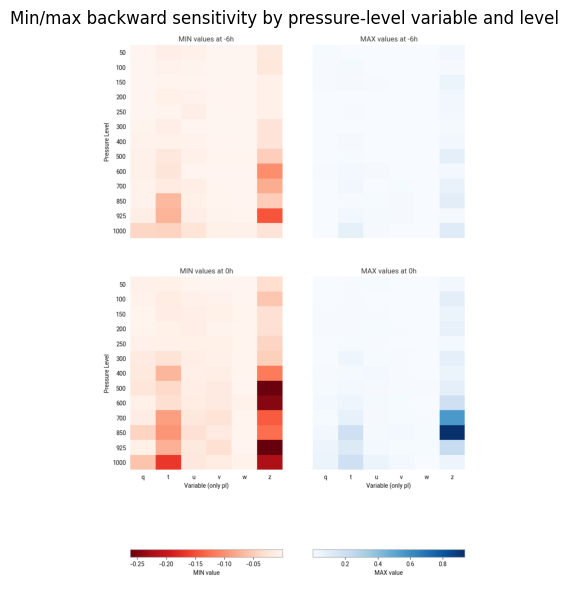

In [2]:
show_artifact("01_pressure_level_summary.png", title="Min/max backward sensitivity by pressure-level variable and level")

## 2. Self-consistency check: 2t sensitivity to itself

Before trusting any cross-variable result, it's worth checking that the
method recovers something unsurprising first: how does the perturbed 2 m
temperature output depend on the *initial* 2 m temperature field? We'd
expect the largest sensitivity right around the perturbation point and along
the recent flow leading into it.

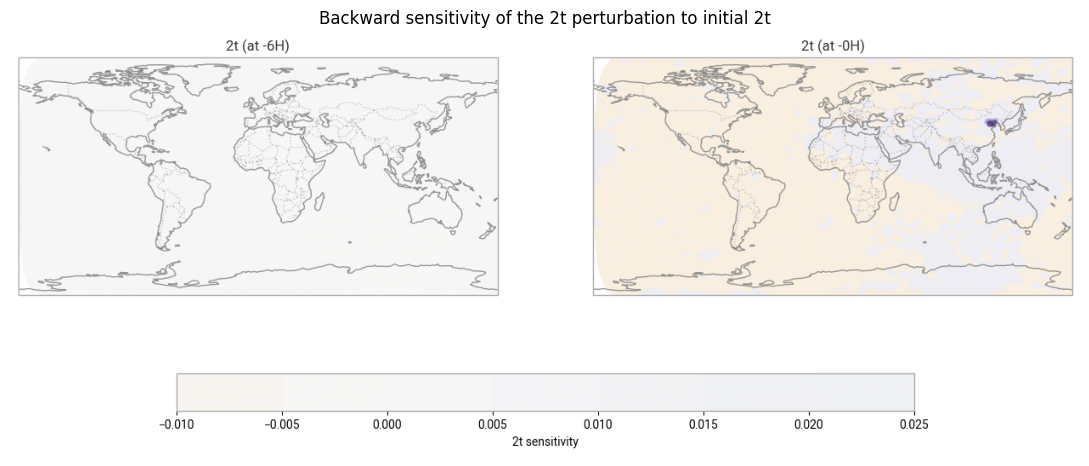

In [3]:
show_artifact("02_map_2t_sensitivity.png", title="Backward sensitivity of the 2t perturbation to initial 2t")

## 3. The cross-variable moment: 500 hPa geopotential

Now the more interesting question: how does that same 2 m temperature
perturbation trace back to the *upper atmosphere*? Here we look at the
sensitivity to 500 hPa geopotential (`z_500`), a classic synoptic-scale
field. A nonzero, spatially coherent sensitivity pattern here -- extending
well beyond the perturbation point -- is AIFS revealing that it has learned
something resembling a physically sensible teleconnection between upper-air
flow and surface temperature, purely from data, without being told any
atmospheric dynamics explicitly.

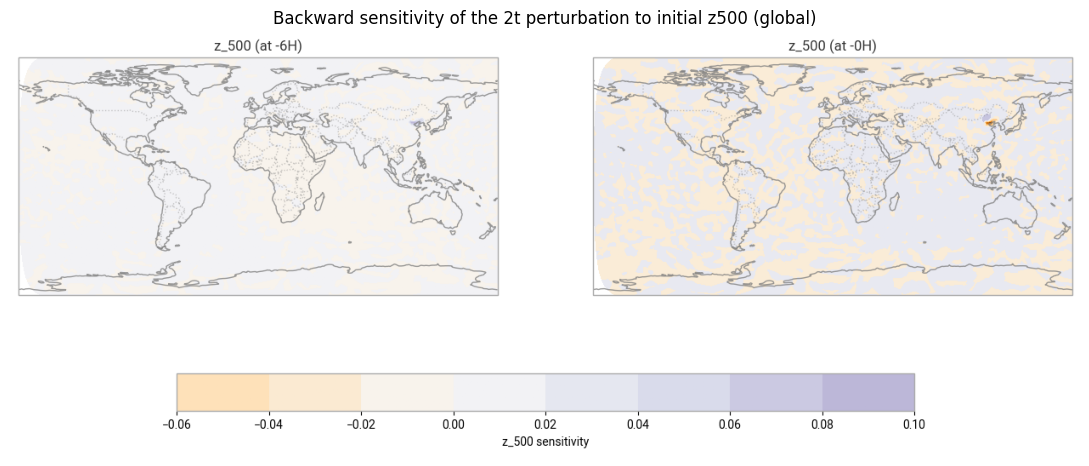

In [4]:
show_artifact("03_map_z500_sensitivity_global.png", title="Backward sensitivity of the 2t perturbation to initial z500 (global)")

## 4. Zooming in

The same `z_500` sensitivity field, cropped to the region surrounding the
perturbation point, showing the spatial structure in more detail.

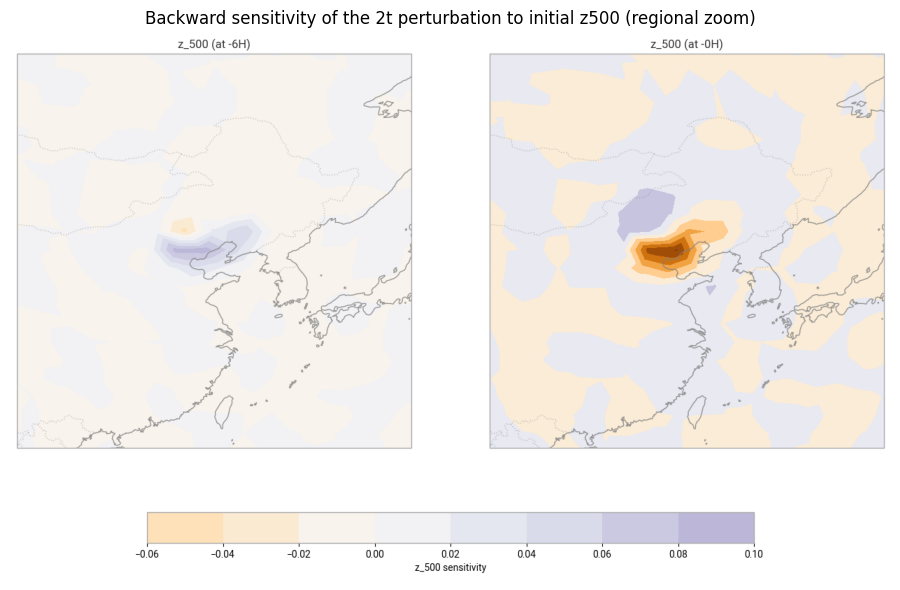

In [5]:
show_artifact("04_map_z500_sensitivity_regional.png", title="Backward sensitivity of the 2t perturbation to initial z500 (regional zoom)")

## 5. The vertical structure

Maps show sensitivity across the horizontal plane at one pressure level.
This cross-section instead fixes latitude (40.5°N, running through the
perturbation point) and shows sensitivity to temperature across *all*
pressure levels at once -- revealing whether the influence is confined near
the surface or extends through the depth of the troposphere.

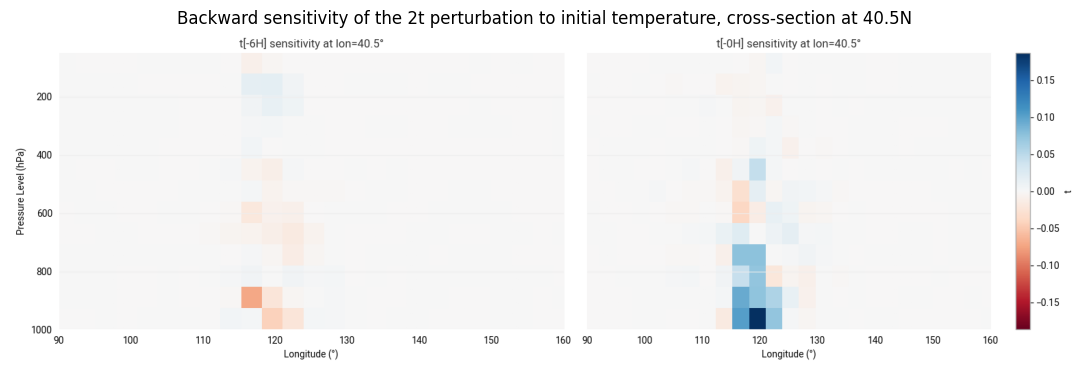

In [6]:
show_artifact("05_cross_section_temperature.png", title="Backward sensitivity of the 2t perturbation to initial temperature, cross-section at 40.5N")

---
## Bridge back: you already know how to think about this

Every method in Part 1 -- tree importance, permutation importance, PDP/ICE,
SHAP -- shares a family resemblance: they are all **perturbation-based** and
(mostly) **model-agnostic**. They probe a model with different inputs and
watch how the output responds, treating the model itself as a black box they
never need to open.

What we just did is different in kind. Backward sensitivities are
**gradient-based** and **model-aware**: computing them requires
differentiating *through* the model's internals via automatic
differentiation, not just querying it from the outside. That requires access
to the model's structure and gradients that black-box methods never touch.

If that sounds familiar, it should. **Adjoint sensitivities are old friends
from numerical weather prediction.** Adjoint models and 4D-Var data
assimilation have used exactly this idea for decades: differentiate a
forecast (or a cost function) with respect to the initial state, to learn
which parts of that state matter most to an outcome downstream. AIFS is a
neural network rather than a physics-based NWP model, and
`torch.autograd.functional.vjp` is doing automatically what an adjoint model
does by hand-derived construction -- but the underlying question, and the
underlying mathematics, are the same one meteorologists and data
assimilation scientists already carry around in their heads.

That's the core message of this workshop: **explainable AI is not a new
skill bolted onto geoscience from the outside. Existing domain expertise
transfers directly into it** -- whether that's the perturbation-based
intuition of Part 1, or the adjoint/sensitivity intuition of Part 2.

## Going further

- Tasks 5.1-5.3 from the original ECMWF course notebook -- change the
  perturbation location, change the perturbation radius, and implement a
  custom `Perturbation` subclass -- are set up as a fully hands-on extension
  using the CPU-feasible O48 checkpoint. See `extensions.md` for a 90-120
  minute version of this session that includes them.
- The live-inference code path (gated behind `RUN_LIVE` below) shows what
  running this yourself would look like, adapted from the source course
  notebook. It is **not executed by this notebook or by CI** -- treat it as
  a reference, not as tested code, and expect to need a GPU-or-CPU machine
  with the full `anemoi-inference` stack installed.

In [7]:
if RUN_LIVE:
    # Reference implementation only -- adapted from ecmwf-training/2025-ml-training's
    # 5-xAI-with-AIFS/explain_AIFS-cpu.ipynb. Not executed by this notebook or by CI.
    # Requires: torch, anemoi-inference, earthkit-data, earthkit-regrid, ecmwf-opendata,
    # cartopy, and the perturbation.py/sensitivities.py/plotting.py/helpers.py helper
    # modules from that course repository (see NOTICE for their Apache-2.0 attribution).
    import subprocess
    from pathlib import Path

    from ecmwf.opendata import Client as OpendataClient

    from helpers import compute_sensitivities_statistics, load_input_state, load_state, save_state
    from perturbation import Perturbation
    from plotting import plot_cross_section, plot_sensitivities, plot_summary_pl
    from sensitivities import SensitivitiesRunner

    # 1. Download the O48 CPU-feasible checkpoint (~180 MB) if not already present.
    ckpt_url = (
        "https://object-store.os-api.cci1.ecmwf.int/ml-tests/test-data/samples/"
        "training-course/inference-aifs-o48-cpu.ckpt"
    )
    ckpt_file = Path("checkpoints/aifs-global-o48-cpu.ckpt")
    ckpt_file.parent.mkdir(parents=True, exist_ok=True)
    if not ckpt_file.exists():
        subprocess.run(["wget", ckpt_url, "-O", str(ckpt_file)], check=True)

    # 2. Load the latest available initial state at O48 resolution.
    date = OpendataClient().latest()
    input_state = load_input_state(date, resolution="O48")

    # 3. Set up the sensitivity runner and the same perturbation used in the figures above.
    runner = SensitivitiesRunner(
        str(ckpt_file), device="cpu", perturb_normalised_space=True, return_unnormalised_sensitivities=False
    )

    class LocalPerturbation(Perturbation):
        def __init__(self, checkpoint, perturbed_variable, perturbation_location, perturbation_radius_km=100.0, **kwargs):
            super().__init__(checkpoint, **kwargs)
            self.perturbed_variable = perturbed_variable
            self.perturbation_location = perturbation_location
            self.perturbation_radius_km = perturbation_radius_km

        def create(self, *args, **kwargs):
            import torch

            from helpers import haversine

            var_idx = self.variable_to_output_tensor_index[self.perturbed_variable]
            perturbation = torch.zeros(self.output_shape)
            dists = haversine(self.coords, torch.tensor(self.perturbation_location))
            closest_idx = torch.where(dists < self.perturbation_radius_km)[0]
            perturbation[..., closest_idx, var_idx] = 1.0
            return perturbation

    perturbation = LocalPerturbation(
        str(ckpt_file), perturbed_variable="2t", perturbation_location=(40, 120), perturbation_radius_km=350.0
    )

    # 4. Run it (only 6h lead time is supported) and reproduce the figures above from fresh output.
    for sensitivities in runner.run(input_state=input_state, perturbation=perturbation, lead_time="6h"):
        pass
    stats_df = compute_sensitivities_statistics(sensitivities)
    plot_summary_pl(stats_df, stats=["min", "max"], cmaps=dict(min="Reds_r", max="Blues"))
    plot_sensitivities(sensitivities, "2t")
    plot_sensitivities(sensitivities, "z_500")
    plot_sensitivities(sensitivities, "z_500", area=(100, 140, 20, 60))
    plot_cross_section("t", sensitivities, latitude=40.5, xlim=(90, 160))
else:
    print("RUN_LIVE is False -- all figures above were loaded from pre-committed artifacts/images/.")

RUN_LIVE is False -- all figures above were loaded from pre-committed artifacts/images/.
